<a href="https://colab.research.google.com/github/MarinPedro/ThermalProject2026_HOCV/blob/main/SCV_P.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Run this command if you want to remove your current folder

In [20]:
!rm -rf /content/lwhsi_dataset/
%mkdir -p /content/lwhsi_dataset
%cd /content/lwhsi_dataset

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
/content/lwhsi_dataset


Loading some data from the 202104 collection of the Darpa Invisible Headlights dataset

In [21]:
!pip install spectral
!pip install awscli -q
!aws s3 sync \
  s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/ \
  /content/lwhsi_dataset/ \
  --no-sign-request \
  --exclude "*" \
  --include "*LWHSI*.hdr" \
  --include "*LWHSI*.bsq" \
  --include "*.las"

download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_LWHSI1_collect0_DistStA.hdr to ./IHTest_202104_Path6_Step9_LWHSI1_collect0_DistStA.hdr
download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_HiResLIDAR_DistStA.las to ./IHTest_202104_Path6_Step9_HiResLIDAR_DistStA.las
download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_LWHSI1_collect1_DistStA.bsq to ./IHTest_202104_Path6_Step9_LWHSI1_collect1_DistStA.bsq
download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_LWHSI1_collect1_DistStA.hdr to ./IHTest_202104_Path6_Step9_LWHSI1_collect1_DistStA.hdr
download: s3://ihdataset-01/IHTest_202104_DistStA/Path6_DistStA/Path6_Step9_DistStA/IHTest_202104_Path6_Step9_LWHSI1_collect3_DistStA.hdr to ./IHTest_202104_Path6_Step9_LWHSI1_collect3_DistStA.hdr
download: s3://ihdataset-

Plotting the images

/tmp/ipykernel_1294/145304641.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


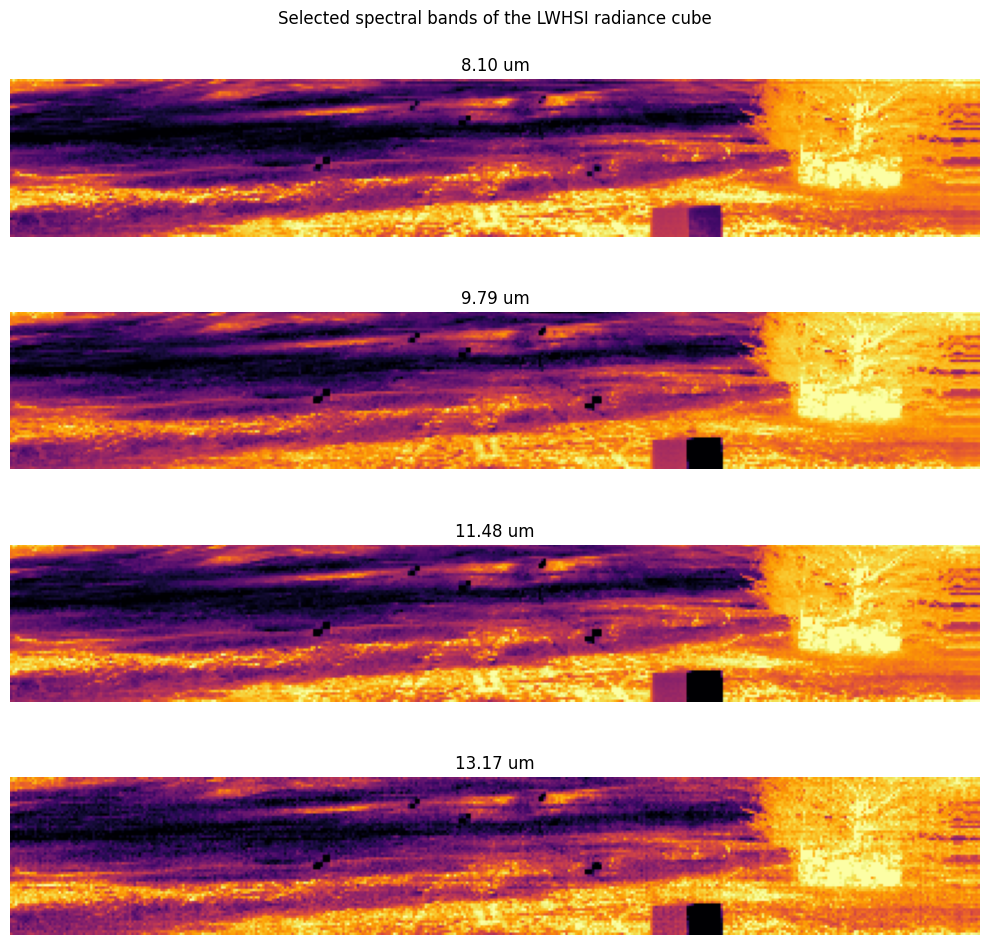

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import spectral.io.envi as envi
import glob

def robust_image(image, low=2, high=98):
    """Normalize an image for display using percentiles."""
    lo, hi = np.percentile(image, [low, high])
    return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)

hdr_files = sorted(glob.glob('/content/lwhsi_dataset/*.hdr', recursive=True))
if not hdr_files:
    raise FileNotFoundError(".hdr files not found")

# There's different images that you can check them by replacing the idx value
idx = 1

try:

  img = envi.open(hdr_files[idx])
  radiance_hsi = img.load()

  if hasattr(img, 'bands') and 'wavelength' in img.metadata:
      wavelengths_um = [float(w) for w in img.metadata['wavelength']]
  else:
      num_bandas = radiance_hsi.shape[2]
      wavelengths_um = np.linspace(8.0, 12.0, num_bandas)

  band_indices = np.linspace(0, len(wavelengths_um) - 1, 4, dtype=int)
  plot_stride = 4

  fig, axes = plt.subplots(len(band_indices), 1, figsize=(10, 10))
  axes = axes.ravel()

  for ax, band_index in zip(axes, band_indices):
      band_image = radiance_hsi[::plot_stride, ::plot_stride, band_index]
      im = ax.imshow(robust_image(band_image), cmap='inferno')
      ax.set_title(f'{wavelengths_um[band_index]:.2f} um')
      ax.axis('off')

  fig.suptitle('Selected spectral bands of the LWHSI radiance cube')
  plt.tight_layout()
  plt.show()

except Exception as e:
  print(e)


Now you can select whatever band you want (the images have a total of 256 bands)

/tmp/ipykernel_1294/145304641.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


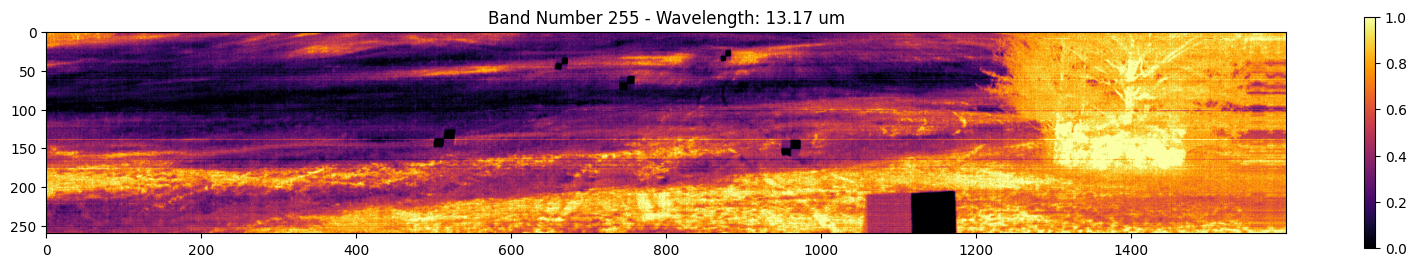

In [27]:
img, axs = plt.subplots(1, 1, figsize=(20, 3))

selected_band = 255

try:

  im = axs.imshow(robust_image(radiance_hsi[:, :, selected_band]), cmap='inferno')
  axs.set_title(f'Band Number {selected_band} - Wavelength: {wavelengths_um[selected_band]:.2f} um')

  axs.label_outer()
  plt.colorbar(im, ax=axs)
  plt.show()

except Exception as e:
  print(e)


Now select the pixels you want to plot (image shape is (260,1600,256)) on the image

In [28]:
selected_pixels = [
    (180, 1050, 1, "Pixel 1"),
    (40, 250, 2, "Pixel 2"),
    (250, 370, 3, "Pixel 3"),
    (252, 273, 4, "Pixel 4")
]

selected_pixels

[(180, 1050, 1, 'Pixel 1'),
 (40, 250, 2, 'Pixel 2'),
 (250, 370, 3, 'Pixel 3'),
 (252, 273, 4, 'Pixel 4')]

We now define the blackbody function

In [29]:
MICROFLICK_PER_W_M2 = 100.0

def blackbody_radiance(wavelenghts_um, temperature_k):
    """Planck blackbody spectral radiance for all bands, in uW / (sr um cm^2)."""
    h = 6.62607015e-34
    c = 299792458.0
    k = 1.380649e-23

    wavelength_m = wavelengths_um * 1e-6

    x = (h * c) / (wavelength_m * k * temperature_k)

    radiance_w_m2_sr_um = (2.0 * h * c**2) / (wavelength_m**5 * np.expm1(x)) * 1e-6
    radiance_microflicks = radiance_w_m2_sr_um * MICROFLICK_PER_W_M2

    return radiance_microflicks.astype(np.float32)

Now select the temperature in Kelvin

In [30]:
temperature_k = 300

/tmp/ipykernel_1294/145304641.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return np.clip((image - lo) / (hi - lo + 1e-12), 0, 1)


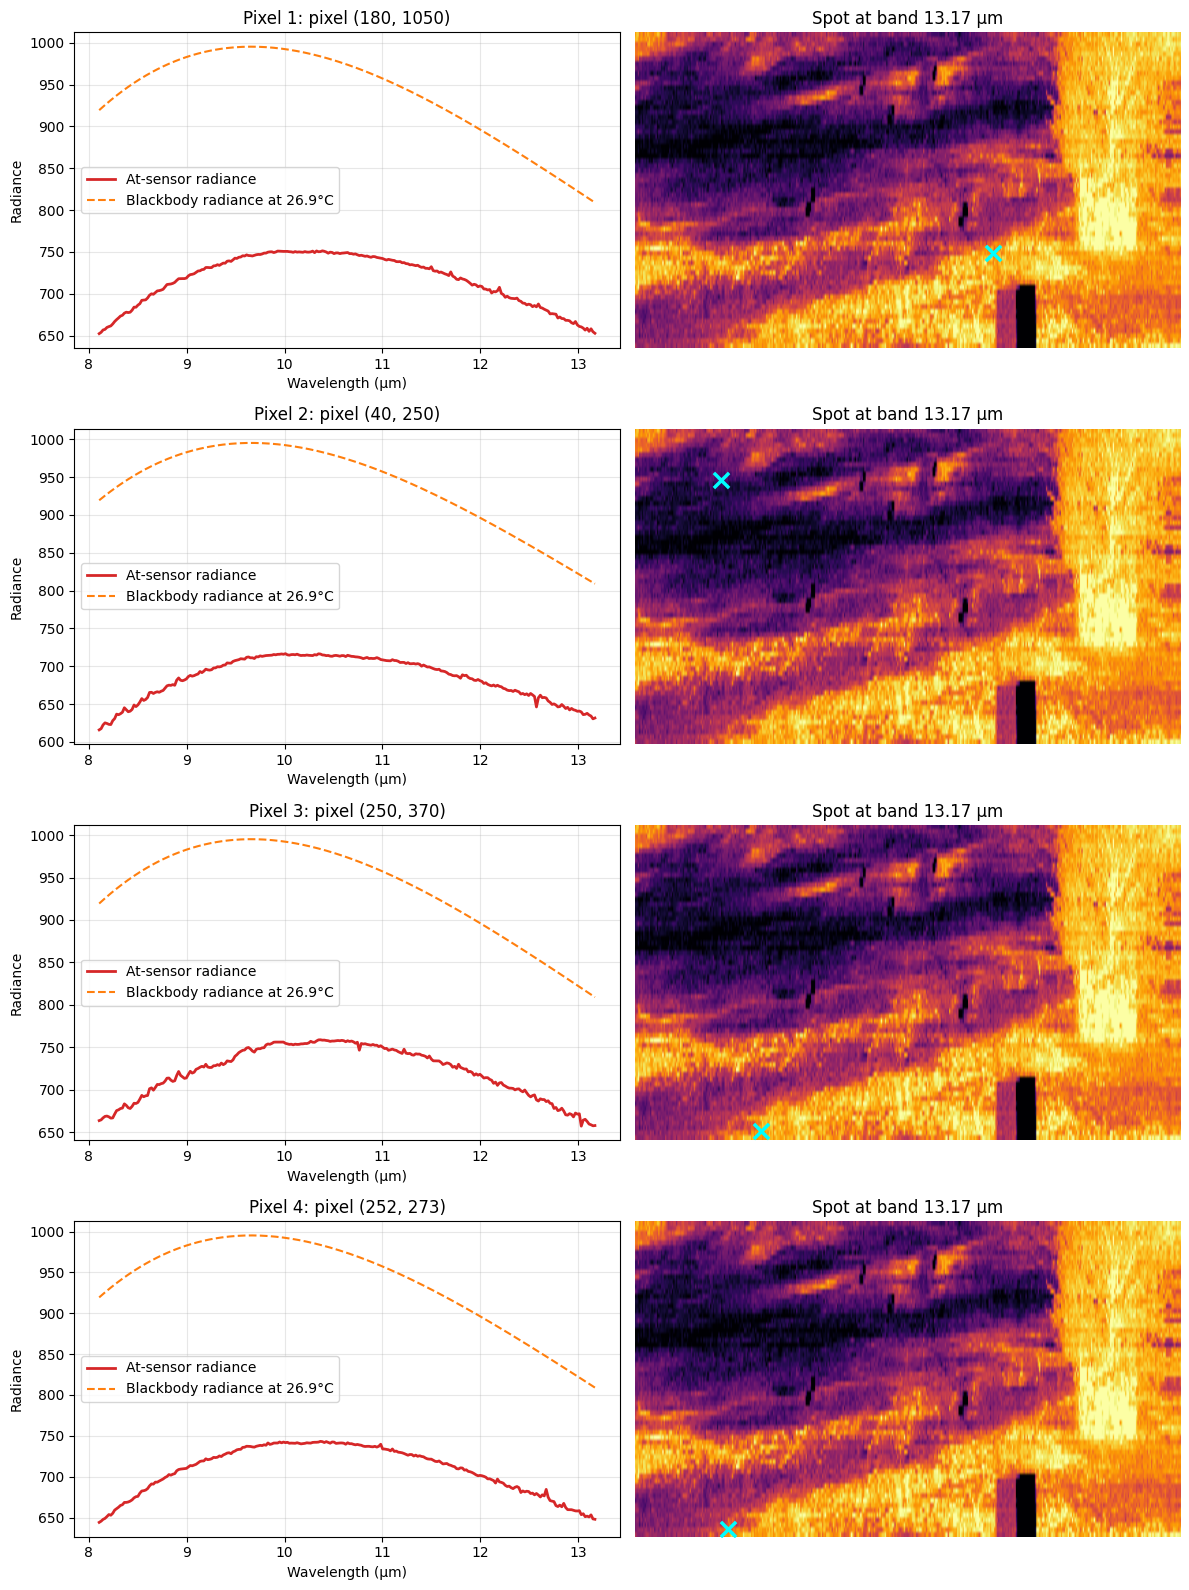

In [31]:
wavelengths_um = np.array(wavelengths_um)
blackbody_curve=blackbody_radiance(wavelengths_um, temperature_k)

context_band = int(np.argmin(np.abs(wavelengths_um - 10.0)))
context_image = robust_image(radiance_hsi[::plot_stride, ::plot_stride, selected_band])

fig, axes = plt.subplots(len(selected_pixels), 2, figsize=(12, 4 * len(selected_pixels)))
if len(selected_pixels) == 1:
    axes = axes[None, :]

for row_axes, (row, col, material_id, material_name) in zip(axes, selected_pixels):
    ax_spec, ax_img = row_axes
    ax_spec.plot(wavelengths_um, radiance_hsi[row, col, :].flatten(), color='tab:red', linewidth=2, label='At-sensor radiance')
    ax_spec.plot(wavelengths_um, blackbody_curve, color='tab:orange', linestyle='--', linewidth=1.5,
                 label=f'Blackbody radiance at {temperature_k-273.15:.1f}°C')
    ax_spec.set_title(f'{material_name}: pixel ({row}, {col})')
    ax_spec.set_xlabel('Wavelength (µm)')
    ax_spec.set_ylabel('Radiance')
    ax_spec.grid(True, alpha=0.3)
    ax_spec.legend()
    ax_img.imshow(context_image, cmap='inferno', aspect='auto')
    ax_img.scatter(col / plot_stride, row / plot_stride, s=120, marker='x', color='cyan', linewidths=2.5)
    ax_img.set_title(f'Spot at band {wavelengths_um[selected_band]:.2f} µm')
    ax_img.axis('off')

plt.tight_layout()
plt.show()